In [1]:
import pandas as pd

# Replace with your CSV file path
pdf = pd.read_csv("AE FINAL.csv")

# Display first 5 rows
pdf.head()

print(pdf.columns)


# Display first 5 rows
pdf.head()
# Check dataset information
pdf.info()

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Create label encoders
le_drug = LabelEncoder()
le_country = LabelEncoder()
le_reporter = LabelEncoder()
le_batch = LabelEncoder()
le_target = LabelEncoder()

# Encode categorical features
pdf["drug_name"] = le_drug.fit_transform(pdf["drug_name"])
pdf["country"] = le_country.fit_transform(pdf["country"])
pdf["reporter_type"] = le_reporter.fit_transform(pdf["reporter_type"])
pdf["batch_id"] = le_batch.fit_transform(pdf["batch_id"])

# Encode target
pdf["event_seriousness"] = le_target.fit_transform(pdf["event_seriousness"])

# Display first rows
pdf.head()

Index(['report_id', 'report_received_date', 'country', 'reporter_type',
       'patient_age', 'is_missing_age', 'patient_sex', 'drug_name',
       'drug_ndc_code', 'indication', 'adverse_event_term',
       'event_seriousness', 'outcome', 'onset_date', 'batch_id',
       'manufacturing_site', 'dose_amount_mg', 'is_missing_dose',
       'route_of_administration', 'concomitant_medications',
       'causality_assessment', 'historical_ae_frequency'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   report_id                81 non-null     str  
 1   report_received_date     81 non-null     str  
 2   country                  81 non-null     str  
 3   reporter_type            81 non-null     str  
 4   patient_age              81 non-null     int64
 5   is_missing_age           81 non-null     int64
 6   patient_sex      

,report_id,report_received_date,country,reporter_type,patient_age,is_missing_age,patient_sex,drug_name,drug_ndc_code,indication,...,outcome,onset_date,batch_id,manufacturing_site,dose_amount_mg,is_missing_dose,route_of_administration,concomitant_medications,causality_assessment,historical_ae_frequency
0,AE-2025-0046,2025-06-26,1,3,52,1,M,7,0781-5566-11,Rheumatoid Arthritis,...,Fatal,2025-06-26,62,MFG-BR-SAO-04,250,0,Topical,NaN,Probable,6
1,AE-2025-0008,2025-09-29,6,6,52,1,M,8,42858-7788-02,Deep Vein Thrombosis,...,Recovered,2025-09-29,5,MFG-DE-BER-02,25,1,Intramuscular,Atorvastatin,Possible,14
2,AE-2025-0030,2025-11-30,0,6,21,0,F,4,0069-5678-02,Generalized Anxiety Disorder,...,Unknown,2025-11-30,42,MFG-IN-HYD-03,25,0,Intramuscular,Metformin,Probable,7
3,AE-2025-0067,2025-11-13,1,0,76,0,M,2,00378-9012-10,Type 2 Diabetes,...,Fatal,2025-11-13,66,MFG-DE-BER-02,25,0,Oral,Metformin,Unrelated,11
4,AE-2025-0003,2025-07-13,8,2,52,1,Unknown,4,0069-5678-02,Generalized Anxiety Disorder,...,recovered,2025-07-13,28,MFG-DE-BER-02,25,1,Subcutaneous,Levothyroxine,Possible,7


In [2]:
print(pdf.columns.tolist())

['report_id', 'report_received_date', 'country', 'reporter_type', 'patient_age', 'is_missing_age', 'patient_sex', 'drug_name', 'drug_ndc_code', 'indication', 'adverse_event_term', 'event_seriousness', 'outcome', 'onset_date', 'batch_id', 'manufacturing_site', 'dose_amount_mg', 'is_missing_dose', 'route_of_administration', 'concomitant_medications', 'causality_assessment', 'historical_ae_frequency']


In [3]:
import pandas as pd

# Replace with your CSV file path
pdf = pd.read_csv("AE FINAL.csv")

# Display first 5 rows
pdf.head()

,report_id,report_received_date,country,reporter_type,patient_age,is_missing_age,patient_sex,drug_name,drug_ndc_code,indication,...,outcome,onset_date,batch_id,manufacturing_site,dose_amount_mg,is_missing_dose,route_of_administration,concomitant_medications,causality_assessment,historical_ae_frequency
0,AE-2025-0046,2025-06-26,Brazil,Other,52,1,M,RHEUMATRIX,0781-5566-11,Rheumatoid Arthritis,...,Fatal,2025-06-26,B1090-B,MFG-BR-SAO-04,250,0,Topical,NaN,Probable,6
1,AE-2025-0008,2025-09-29,Japan,physician,52,1,M,VASCULIN,42858-7788-02,Deep Vein Thrombosis,...,Recovered,2025-09-29,B1008-C,MFG-DE-BER-02,25,1,Intramuscular,Atorvastatin,Possible,14
2,AE-2025-0030,2025-11-30,Australia,physician,21,0,F,NEUROLEX,0069-5678-02,Generalized Anxiety Disorder,...,Unknown,2025-11-30,B1059-C,MFG-IN-HYD-03,25,0,Intramuscular,Metformin,Probable,7
3,AE-2025-0067,2025-11-13,Brazil,Consumer,76,0,M,GLUCOMEND,00378-9012-10,Type 2 Diabetes,...,Fatal,2025-11-13,B1095-B,MFG-DE-BER-02,25,0,Oral,Metformin,Unrelated,11
4,AE-2025-0003,2025-07-13,United Kingdom,Nurse,52,1,Unknown,NEUROLEX,0069-5678-02,Generalized Anxiety Disorder,...,recovered,2025-07-13,B1037-A,MFG-DE-BER-02,25,1,Subcutaneous,Levothyroxine,Possible,7


In [4]:
print(pdf.columns)

Index(['report_id', 'report_received_date', 'country', 'reporter_type',
       'patient_age', 'is_missing_age', 'patient_sex', 'drug_name',
       'drug_ndc_code', 'indication', 'adverse_event_term',
       'event_seriousness', 'outcome', 'onset_date', 'batch_id',
       'manufacturing_site', 'dose_amount_mg', 'is_missing_dose',
       'route_of_administration', 'concomitant_medications',
       'causality_assessment', 'historical_ae_frequency'],
      dtype='str')


In [5]:
# Standardize text
pdf["causality_assessment"] = (
    pdf["causality_assessment"]
    .astype(str)
    .str.strip()      # Remove leading/trailing spaces
    .str.title()      # Convert to Title Case
)

In [6]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoders
le_drug = LabelEncoder()
le_country = LabelEncoder()
le_reporter = LabelEncoder()
le_batch = LabelEncoder()
le_target = LabelEncoder()

# Encode feature columns
pdf["drug_name"] = le_drug.fit_transform(pdf["drug_name"])
pdf["country"] = le_country.fit_transform(pdf["country"])
pdf["reporter_type"] = le_reporter.fit_transform(pdf["reporter_type"])
pdf["batch_id"] = le_batch.fit_transform(pdf["batch_id"])

# Encode target column
pdf["causality_assessment"] = le_target.fit_transform(pdf["causality_assessment"])

In [7]:
import pandas as pd

pdf["patient_age"] = pd.to_numeric(pdf["patient_age"], errors="coerce")
pdf["dose_amount_mg"] = pd.to_numeric(pdf["dose_amount_mg"], errors="coerce")
pdf["historical_ae_frequency"] = pd.to_numeric(
    pdf["historical_ae_frequency"],
    errors="coerce"
)

In [8]:
print(pdf.isnull().sum())

report_id                   0
report_received_date        0
country                     0
reporter_type               0
patient_age                 0
is_missing_age              0
patient_sex                 0
drug_name                   0
drug_ndc_code               0
indication                  0
adverse_event_term          0
event_seriousness           0
outcome                     0
onset_date                  0
batch_id                    0
manufacturing_site          0
dose_amount_mg              0
is_missing_dose             0
route_of_administration     0
concomitant_medications    10
causality_assessment        0
historical_ae_frequency     0
dtype: int64


In [9]:
pdf = pdf.fillna(pdf.median(numeric_only=True))

In [10]:
X = pdf[
    [
        "patient_age",
        "drug_name",
        "dose_amount_mg",
        "country",
        "reporter_type",
        "batch_id",
        "historical_ae_frequency",
    ]
]

y = pdf["causality_assessment"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (81, 7)
Target Shape   : (81,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 64
Testing Samples  : 17


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    log_loss
)

# Multinomial Logistic Regression
log_model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

# Train model
log_model.fit(X_train, y_train)

print('Multinomial Logistic Regression model trained successfully!')

# Predictions
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)

# Evaluation
print('\nAccuracy :', accuracy_score(y_test, y_pred_log))
print('Precision:', precision_score(y_test, y_pred_log, average='macro'))
print('Recall   :', recall_score(y_test, y_pred_log, average='macro'))
print('F1 Score :', f1_score(y_test, y_pred_log, average='macro'))
print('Log Loss :', log_loss(y_test, y_prob_log))

print('\nClassification Report')
print(classification_report(y_test, y_pred_log))

print('\nConfusion Matrix')
print(confusion_matrix(y_test, y_pred_log))

Multinomial Logistic Regression model trained successfully!

Accuracy : 0.23529411764705882
Precision: 0.16666666666666666
Recall   : 0.16666666666666666
F1 Score : 0.16
Log Loss : 1.8607159708960292

Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      0.50      0.40         6
           2       0.00      0.00      0.00         3
           3       0.50      0.33      0.40         3
           4       0.00      0.00      0.00         3

    accuracy                           0.24        17
   macro avg       0.17      0.17      0.16        17
weighted avg       0.21      0.24      0.21        17


Confusion Matrix
[[0 1 1 0 0]
 [0 3 1 0 2]
 [0 2 0 1 0]
 [0 1 0 1 1]
 [1 2 0 0 0]]


C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
from xgboost import XGBClassifier

# Create model
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(y.unique()),
    eval_metric="mlogloss",
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

print("XGBoost Multi-class model trained successfully!")

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)

# Evaluation
print("\nAccuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb, average="macro"))
print("Recall   :", recall_score(y_test, y_pred_xgb, average="macro"))
print("F1 Score :", f1_score(y_test, y_pred_xgb, average="macro"))
print("Log Loss :", log_loss(y_test, y_prob_xgb))

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Multi-class model trained successfully!

Accuracy : 0.23529411764705882
Precision: 0.11000000000000001
Recall   : 0.16666666666666666
F1 Score : 0.13214285714285715
Log Loss : 2.994501829147339

Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.30      0.50      0.38         6
           2       0.25      0.33      0.29         3
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         3

    accuracy                           0.24        17
   macro avg       0.11      0.17      0.13        17
weighted avg       0.15      0.24      0.18        17


Confusion Matrix
[[0 1 1 0 0]
 [0 3 1 1 1]
 [0 2 1 0 0]
 [0 3 0 0 0]
 [1 1 1 0 0]]


## Model Comparison

In [14]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Multinomial Logistic Regression", "XGBoost Multi-class"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision (Macro)": [
        precision_score(y_test, y_pred_log, average="macro"),
        precision_score(y_test, y_pred_xgb, average="macro")
    ],
    "Recall (Macro)": [
        recall_score(y_test, y_pred_log, average="macro"),
        recall_score(y_test, y_pred_xgb, average="macro")
    ],
    "F1 Score (Macro)": [
        f1_score(y_test, y_pred_log, average="macro"),
        f1_score(y_test, y_pred_xgb, average="macro")
    ],
    "Log Loss": [
        log_loss(y_test, y_prob_log),
        log_loss(y_test, y_prob_xgb)
    ]
})

comparison

,Model,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro),Log Loss
0,Multinomial Logistic Regression,0.235294,0.166667,0.166667,0.160000,1.860716
1,XGBoost Multi-class,0.235294,0.110000,0.166667,0.132143,2.994502


In [15]:
print(pdf.columns.tolist())

['report_id', 'report_received_date', 'country', 'reporter_type', 'patient_age', 'is_missing_age', 'patient_sex', 'drug_name', 'drug_ndc_code', 'indication', 'adverse_event_term', 'event_seriousness', 'outcome', 'onset_date', 'batch_id', 'manufacturing_site', 'dose_amount_mg', 'is_missing_dose', 'route_of_administration', 'concomitant_medications', 'causality_assessment', 'historical_ae_frequency']


# PLOTS

## Bar Charts

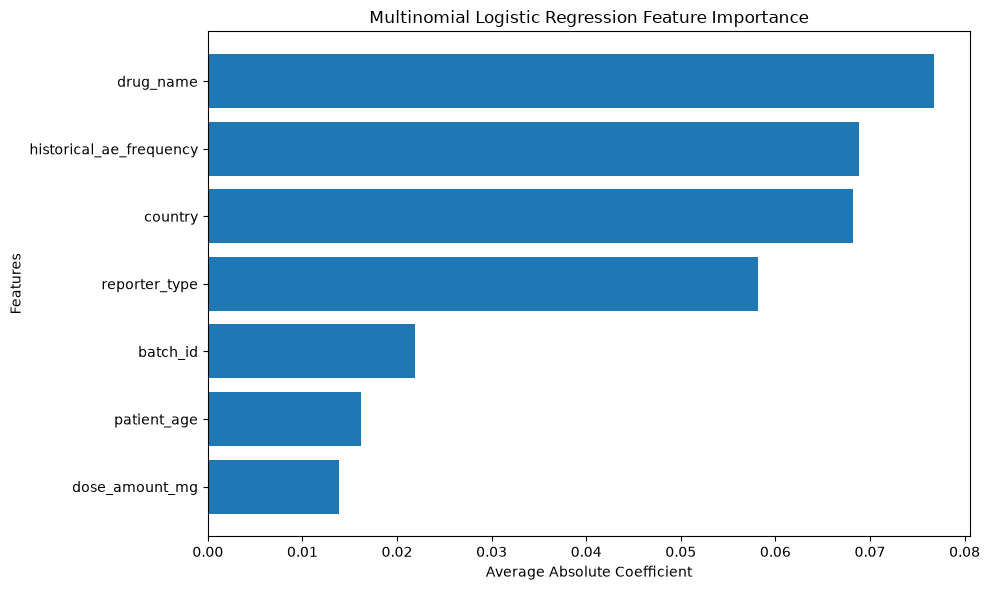

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Calculate average absolute coefficient importance
importance = np.mean(np.abs(log_model.coef_), axis=0)

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

# Sort
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Plot
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.xlabel('Average Absolute Coefficient')
plt.ylabel('Features')
plt.title('Multinomial Logistic Regression Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Pie Chart

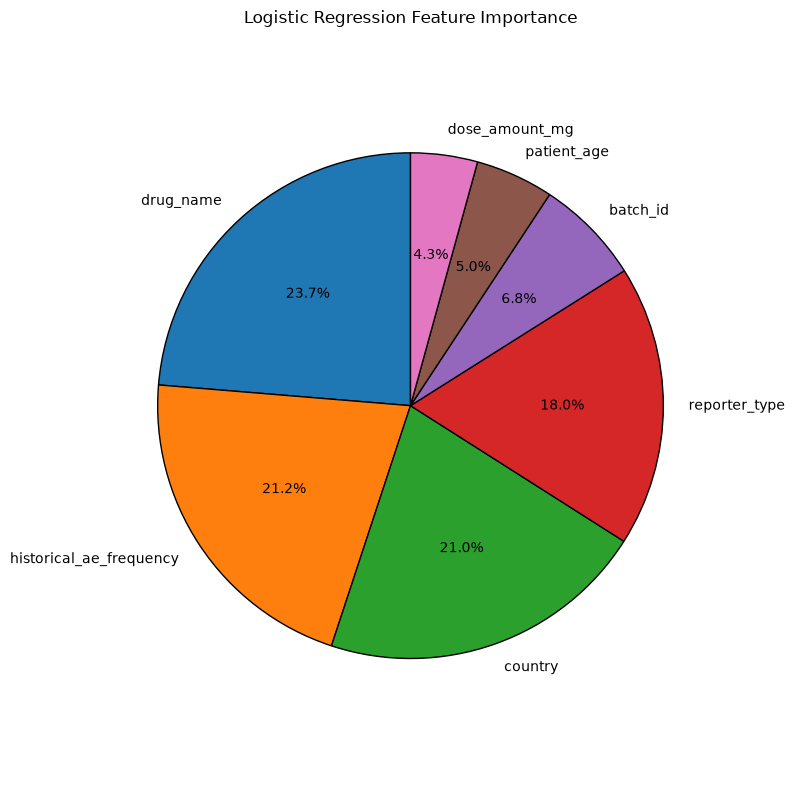

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Calculate average absolute coefficient importance
importance = np.mean(np.abs(log_model.coef_), axis=0)

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Pie Chart
plt.figure(figsize=(8,8))

plt.pie(
    feature_importance["Importance"],
    labels=feature_importance["Feature"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black"}
)

plt.title("Logistic Regression Feature Importance")

plt.axis("equal")

plt.tight_layout()

plt.show()

## Confusion Matrix

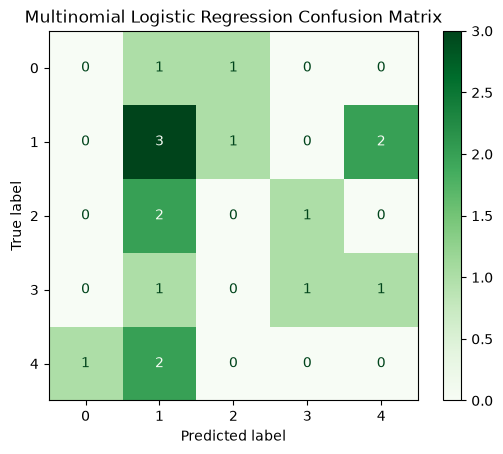

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    log_model,
    X_test,
    y_test,
    cmap='Greens'
)

plt.title('Multinomial Logistic Regression Confusion Matrix')
plt.show()

## ROC Comparison Curve

Classes: [0 1 2 3 4]
Number of classes: 5


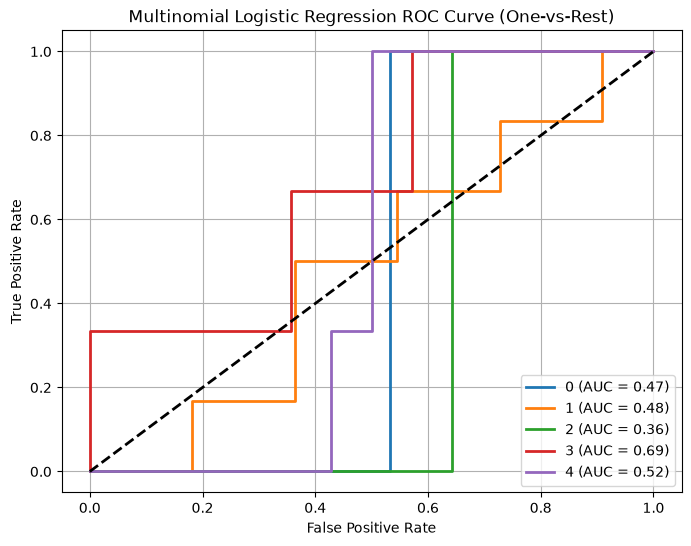

In [19]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Get unique classes
classes = np.unique(y_test)

print('Classes:', classes)
print('Number of classes:', len(classes))

# Convert labels to binary format
y_test_bin = label_binarize(y_test, classes=classes)

# Predicted probabilities from Logistic Regression
y_score = log_model.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'{classes[i]} (AUC = {roc_auc:.2f})'
    )

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multinomial Logistic Regression ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

In [20]:
print(pdf["causality_assessment"].unique())
print(pdf["causality_assessment"].value_counts())
print("Number of classes:", pdf["causality_assessment"].nunique())
print("Encoded classes:", le_target.classes_)

[2 1 4 0 3]
causality_assessment
1    31
4    14
3    14
2    13
0     9
Name: count, dtype: int64
Number of classes: 5
Encoded classes: ['Certain' 'Possible' 'Probable' 'Unlikely' 'Unrelated']


# SHAP

## SHAP Interaction Summary Plot

C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


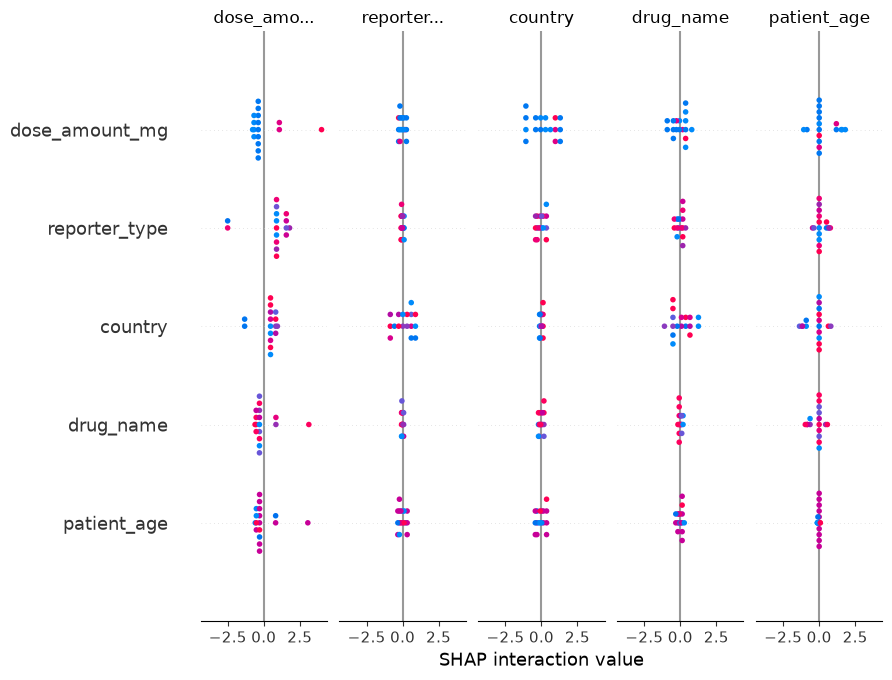

In [21]:
import shap
import matplotlib.pyplot as plt

# Create SHAP explainer
explainer = shap.LinearExplainer(log_model, X_train)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

# Summary Plot
shap.summary_plot(shap_values, X_test)

## SHAP Multi-class Feature Importance Summary Plot

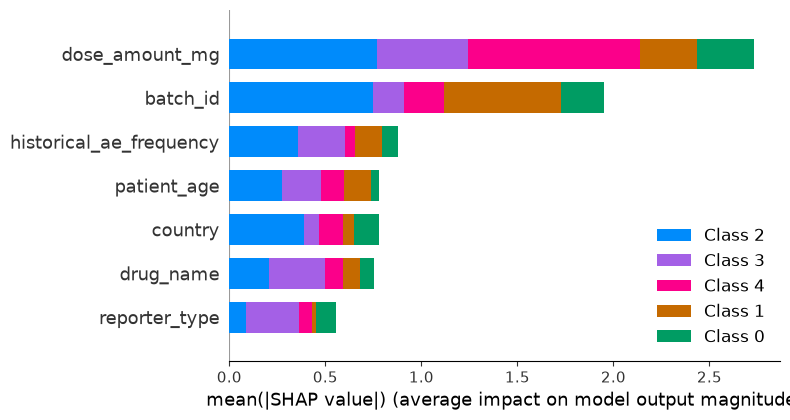

In [22]:
import shap

explainer = shap.LinearExplainer(log_model, X_train)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

## SHAP Summary Plot (Beeswarm Plot)

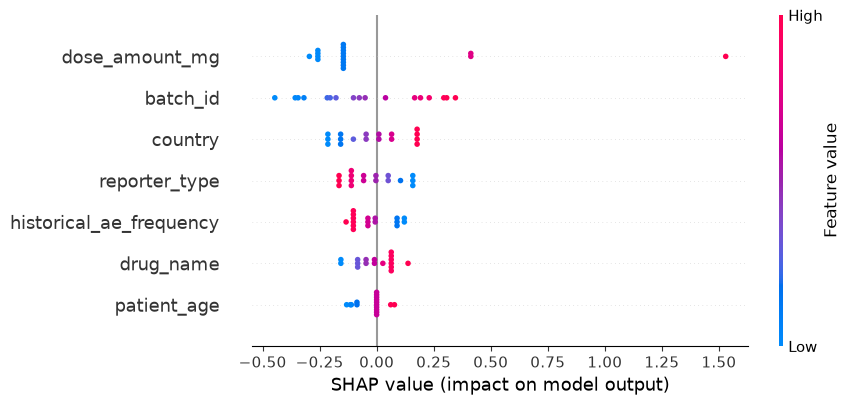

In [23]:
import shap

explainer = shap.LinearExplainer(log_model, X_train)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap.Explanation(
    values=shap_values.values[:, :, 0],
    base_values=shap_values.base_values[:, 0],
    data=X_test.values,
    feature_names=X_test.columns
))

## SHAP Waterfall Plot

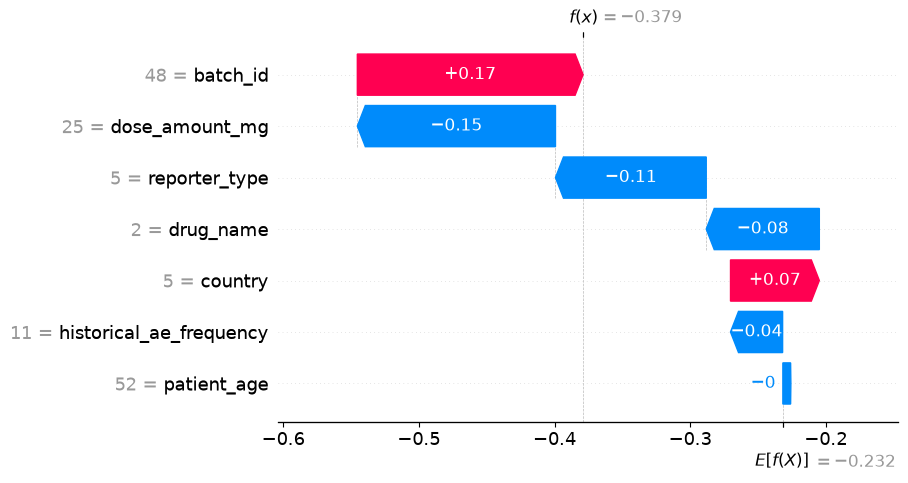

In [24]:
import shap

explainer = shap.LinearExplainer(log_model, X_train)
shap_values = explainer(X_test)

exp = shap.Explanation(
    values=shap_values.values[0, :, 0],
    base_values=shap_values.base_values[0, 0],
    data=X_test.iloc[0],
    feature_names=X_test.columns
)

shap.plots.waterfall(exp)

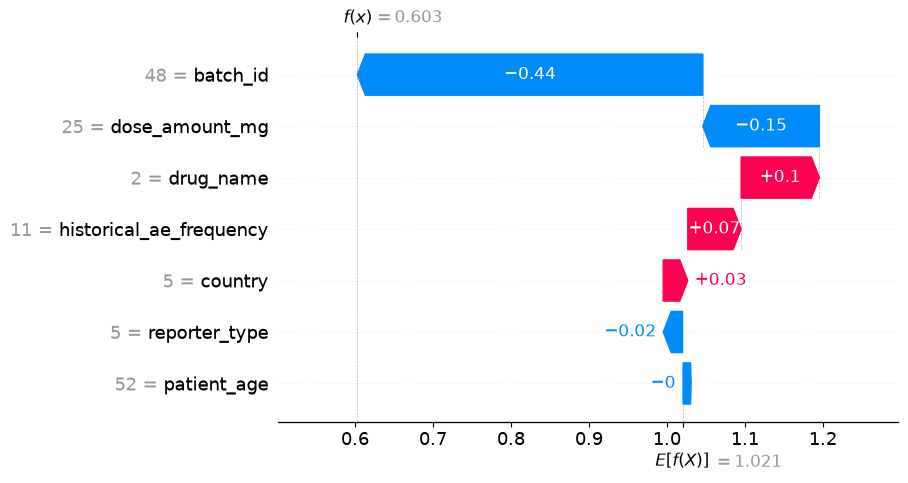

In [25]:
exp = shap.Explanation(
    values=shap_values.values[0, :, 1],
    base_values=shap_values.base_values[0, 1],
    data=X_test.iloc[0],
    feature_names=X_test.columns
)

shap.plots.waterfall(exp)

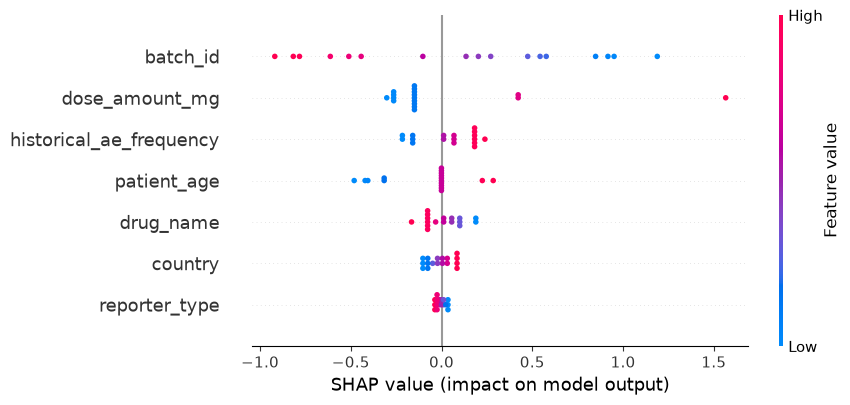

In [26]:
shap.plots.beeswarm(shap.Explanation(
    values=shap_values.values[:, :, 1],
    base_values=shap_values.base_values[:, 1],
    data=X_test.values,
    feature_names=X_test.columns
))

## SHAP Violin Summary Plot

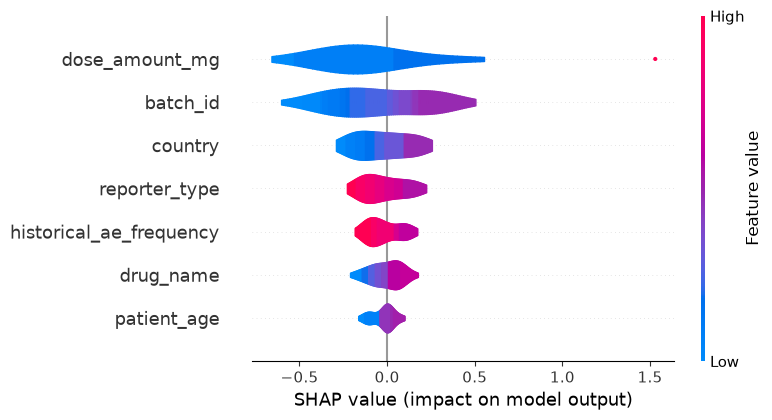

In [27]:
import shap
import matplotlib.pyplot as plt

# Select SHAP values for one class
class_idx = 0

shap_class = shap.Explanation(
    values=shap_values.values[:, :, class_idx],
    base_values=shap_values.base_values[:, class_idx],
    data=X_test.values,
    feature_names=X_test.columns
)

plt.figure(figsize=(10,6))

shap.plots.violin(
    shap_class,
    show=False
)

plt.tight_layout()
plt.show()

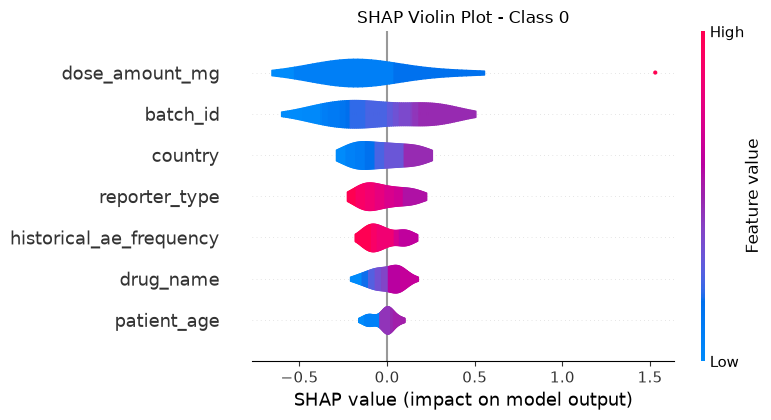

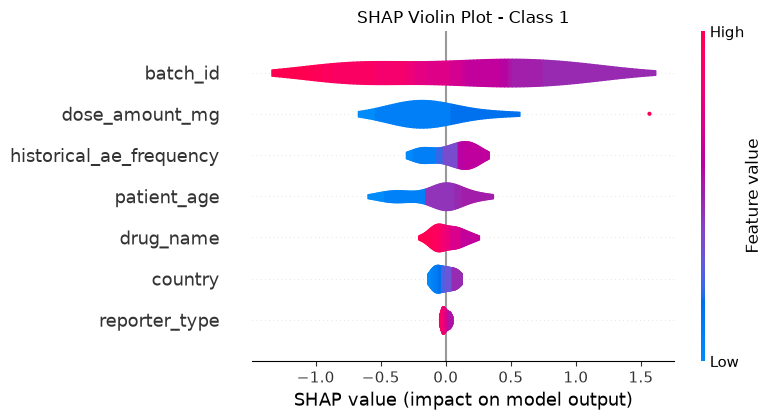

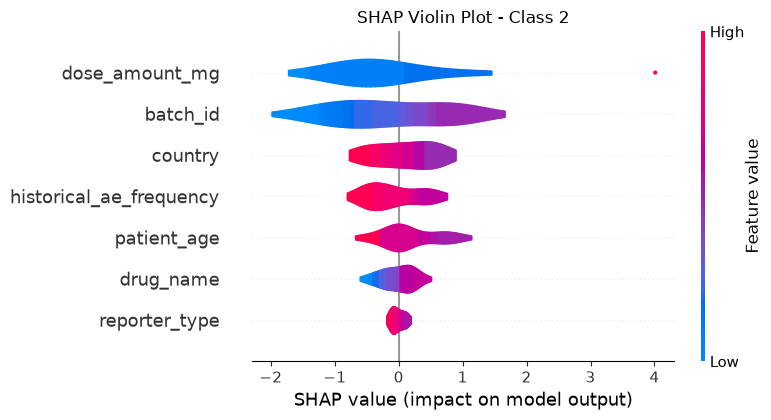

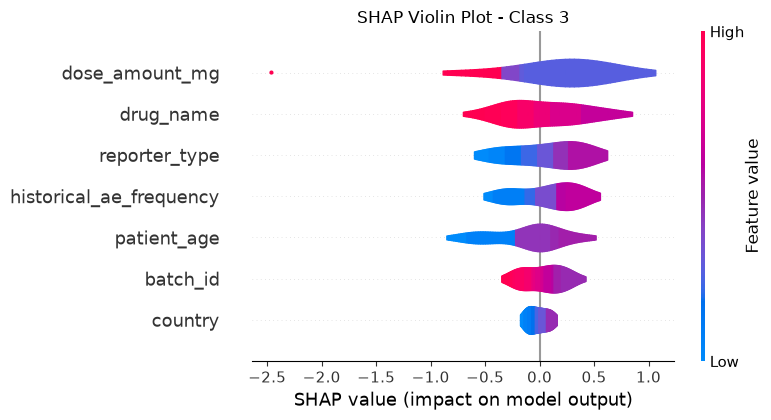

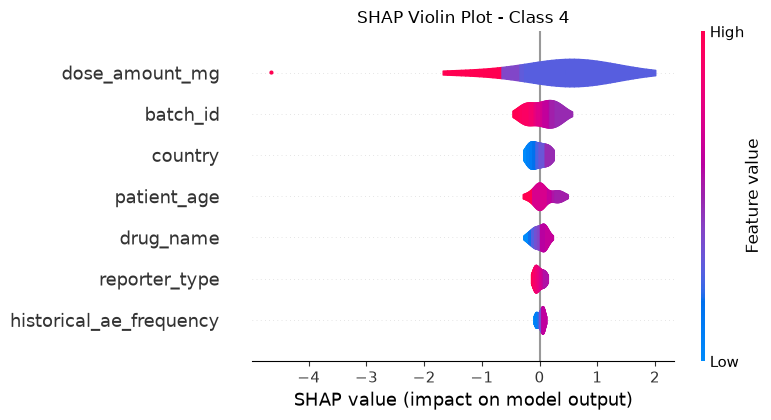

In [28]:
for i in range(shap_values.values.shape[2]):

    shap_class = shap.Explanation(
        values=shap_values.values[:, :, i],
        base_values=shap_values.base_values[:, i],
        data=X_test.values,
        feature_names=X_test.columns
    )

    plt.figure(figsize=(10,6))

    shap.plots.violin(
        shap_class,
        show=False
    )

    plt.title(f"SHAP Violin Plot - Class {i}")

    plt.tight_layout()

    plt.show()

In [29]:
best_model = log_model
best_pred = y_pred_log
best_prob = log_model.predict_proba(X_test)

In [31]:
import os
import json
import joblib
import pandas as pd
import shap

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    log_loss
)

# =====================================================
# SELECT BEST MODEL
# =====================================================

# Uncomment the best model

# XGBoost
# best_model = xgb_model
# best_pred = y_pred_xgb
# best_prob = y_prob_xgb

# Logistic Regression
# best_model = log_model
# best_pred = y_pred_log
# best_prob = y_prob_log

# =====================================================
# CREATE FOLDER STRUCTURE
# =====================================================

BASE_DIR = "models"
ROOT_DIR = os.path.join(BASE_DIR, "causality")

MODEL_DIR = os.path.join(ROOT_DIR, "model")
METRIC_DIR = os.path.join(ROOT_DIR, "metrics")
PLOT_DIR = os.path.join(ROOT_DIR, "plots")
PREDICTION_DIR = os.path.join(ROOT_DIR, "predictions")
SHAP_DIR = os.path.join(ROOT_DIR, "shap")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(METRIC_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(PREDICTION_DIR, exist_ok=True)
os.makedirs(SHAP_DIR, exist_ok=True)

print("Folders Created Successfully")

# =====================================================
# SAVE MODEL
# =====================================================

joblib.dump(
    best_model,
    os.path.join(MODEL_DIR, "causality_model.pkl")
)

# =====================================================
# SAVE LABEL ENCODERS
# =====================================================

joblib.dump(le_drug,
            os.path.join(MODEL_DIR, "le_drug.pkl"))

joblib.dump(le_country,
            os.path.join(MODEL_DIR, "le_country.pkl"))

joblib.dump(le_reporter,
            os.path.join(MODEL_DIR, "le_reporter.pkl"))

joblib.dump(le_batch,
            os.path.join(MODEL_DIR, "le_batch.pkl"))

joblib.dump(le_target,
            os.path.join(MODEL_DIR, "le_target.pkl"))

# =====================================================
# SAVE FEATURE COLUMNS
# =====================================================

joblib.dump(
    list(X.columns),
    os.path.join(
        MODEL_DIR,
        "feature_columns.pkl"
    )
)

# =====================================================
# SAVE METRICS
# =====================================================

metrics = {

    "accuracy": float(
        accuracy_score(
            y_test,
            best_pred
        )
    ),

    "precision": float(
        precision_score(
            y_test,
            best_pred,
            average="macro"
        )
    ),

    "recall": float(
        recall_score(
            y_test,
            best_pred,
            average="macro"
        )
    ),

    "f1_score": float(
        f1_score(
            y_test,
            best_pred,
            average="macro"
        )
    ),

    "log_loss": float(
        log_loss(
            y_test,
            best_prob
        )
    )

}

with open(
    os.path.join(
        METRIC_DIR,
        "metrics.json"
    ),
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

print("Metrics Saved")

# =====================================================
# SAVE CLASSIFICATION REPORT
# =====================================================

with open(
    os.path.join(
        METRIC_DIR,
        "classification_report.txt"
    ),
    "w"
) as f:

    f.write(
        classification_report(
            y_test,
            best_pred
        )
    )

print("Classification Report Saved")

# =====================================================
# SAVE CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    best_pred
)

joblib.dump(
    cm,
    os.path.join(
        METRIC_DIR,
        "confusion_matrix.pkl"
    )
)

print("Confusion Matrix Saved")

# =====================================================
# SAVE PREDICTIONS
# =====================================================

prediction_df = pd.DataFrame({

    "Actual": le_target.inverse_transform(y_test),

    "Predicted":
    le_target.inverse_transform(best_pred)

})

prediction_df.to_csv(

    os.path.join(
        PREDICTION_DIR,
        "predictions.csv"
    ),

    index=False

)

print("Predictions Saved")

# =====================================================
# CREATE SHAP EXPLAINER
# =====================================================

try:

    if best_model == xgb_model:

        explainer = shap.TreeExplainer(
            best_model
        )

        shap_values = explainer.shap_values(
            X_test
        )

    else:

        explainer = shap.LinearExplainer(
            best_model,
            X_train
        )

        shap_values = explainer.shap_values(
            X_test
        )

    joblib.dump(

        explainer,

        os.path.join(
            SHAP_DIR,
            "shap_explainer.pkl"
        )

    )

    joblib.dump(

        shap_values,

        os.path.join(
            SHAP_DIR,
            "shap_values.pkl"
        )

    )

    print("SHAP Objects Saved")

except Exception as e:

    print(e)

print("\n===================================")
print("PART 1 COMPLETED SUCCESSFULLY")
print("===================================")

Folders Created Successfully
Metrics Saved
Classification Report Saved
Confusion Matrix Saved
Predictions Saved
SHAP Objects Saved

PART 1 COMPLETED SUCCESSFULLY


In [32]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

# =====================================================
# PLOT DIRECTORY
# =====================================================

PLOT_DIR = os.path.join("models", "causality", "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

# =====================================================
# FEATURE IMPORTANCE
# =====================================================

if best_model == log_model:

    importance = np.mean(
        np.abs(log_model.coef_),
        axis=0
    )

else:

    importance = best_model.feature_importances_

feature_importance = pd.DataFrame({

    "Feature": X_train.columns,
    "Importance": importance

}).sort_values(
    by="Importance",
    ascending=False
)

# Save Importance Table
joblib.dump(
    feature_importance,
    os.path.join(
        PLOT_DIR,
        "feature_importance.pkl"
    )
)

# =====================================================
# HORIZONTAL BAR PLOT
# =====================================================

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "feature_importance_bar.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Bar Plot Saved")

# =====================================================
# PIE CHART
# =====================================================

plt.figure(figsize=(8,8))

plt.pie(

    feature_importance["Importance"],

    labels=feature_importance["Feature"],

    autopct="%1.1f%%",

    startangle=90,

    wedgeprops={
        "edgecolor":"black"
    }

)

plt.title("Feature Importance Distribution")

plt.axis("equal")

plt.tight_layout()

plt.savefig(

    os.path.join(
        PLOT_DIR,
        "feature_importance_pie.png"
    ),

    dpi=300,

    bbox_inches="tight"

)

plt.close()

print("Pie Chart Saved")

# =====================================================
# CONFUSION MATRIX HEATMAP
# =====================================================

plt.figure(figsize=(8,6))

ConfusionMatrixDisplay.from_predictions(

    y_test,

    best_pred,

    cmap="Blues"

)

plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(

    os.path.join(
        PLOT_DIR,
        "confusion_matrix_heatmap.png"
    ),

    dpi=300,

    bbox_inches="tight"

)

plt.close()

print("Confusion Matrix Saved")

# =====================================================
# ROC CURVE
# =====================================================

classes = np.unique(y_test)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

plt.figure(figsize=(8,6))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(

        y_test_bin[:,i],

        best_prob[:,i]

    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(

        fpr,

        tpr,

        lw=2,

        label=f"{classes[i]} (AUC={roc_auc:.2f})"

    )

plt.plot(

    [0,1],

    [0,1],

    "k--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve (One-vs-Rest)")

plt.legend(loc="lower right")

plt.grid(True)

plt.tight_layout()

plt.savefig(

    os.path.join(
        PLOT_DIR,
        "roc_curve.png"
    ),

    dpi=300,

    bbox_inches="tight"

)

plt.close()

print("ROC Curve Saved")

print("\n========================================")
print("PART 2 COMPLETED SUCCESSFULLY")
print("========================================")
print("✔ Feature Importance PKL")
print("✔ Horizontal Bar Plot")
print("✔ Feature Importance Pie Chart")
print("✔ Confusion Matrix Heatmap")
print("✔ ROC Curve")
print("========================================")

Bar Plot Saved
Pie Chart Saved
Confusion Matrix Saved
ROC Curve Saved

PART 2 COMPLETED SUCCESSFULLY
✔ Feature Importance PKL
✔ Horizontal Bar Plot
✔ Feature Importance Pie Chart
✔ Confusion Matrix Heatmap
✔ ROC Curve


<Figure size 800x600 with 0 Axes>

In [33]:
# =====================================================
# PART 3 - SHAP PLOTS
# =====================================================

import os
import joblib
import shap
import matplotlib.pyplot as plt

SHAP_DIR = os.path.join("models", "causality", "shap")
PLOT_DIR = os.path.join("models", "causality", "plots")

os.makedirs(SHAP_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# =====================================================
# CREATE SHAP EXPLAINER
# =====================================================

if best_model == log_model:

    explainer = shap.LinearExplainer(
        best_model,
        X_train
    )

    shap_values = explainer(X_test)

else:

    explainer = shap.TreeExplainer(
        best_model
    )

    shap_values = explainer(X_test)

# =====================================================
# SAVE SHAP OBJECTS
# =====================================================

joblib.dump(
    explainer,
    os.path.join(
        SHAP_DIR,
        "shap_explainer.pkl"
    )
)

joblib.dump(
    shap_values,
    os.path.join(
        SHAP_DIR,
        "shap_values.pkl"
    )
)

print("SHAP Objects Saved")

# =====================================================
# SUMMARY PLOT
# =====================================================

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "shap_summary.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# =====================================================
# SUMMARY BAR
# =====================================================

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "shap_summary_bar.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# =====================================================
# BEESWARM
# =====================================================

class_idx = 0

shap_class = shap.Explanation(

    values=shap_values.values[:, :, class_idx],

    base_values=shap_values.base_values[:, class_idx],

    data=X_test.values,

    feature_names=X_test.columns

)

plt.figure(figsize=(10,6))

shap.plots.beeswarm(
    shap_class,
    show=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "shap_beeswarm.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# =====================================================
# WATERFALL
# =====================================================

waterfall_exp = shap.Explanation(

    values=shap_values.values[0, :, class_idx],

    base_values=shap_values.base_values[0, class_idx],

    data=X_test.iloc[0],

    feature_names=X_test.columns

)

plt.figure(figsize=(10,6))

shap.plots.waterfall(
    waterfall_exp,
    show=False
)

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "shap_waterfall.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("====================================")
print("PART 3 COMPLETED")
print("====================================")
print("✔ SHAP Explainer Saved")
print("✔ SHAP Values Saved")
print("✔ SHAP Summary Plot")
print("✔ SHAP Summary Bar")
print("✔ SHAP Beeswarm")
print("✔ SHAP Waterfall")
print("====================================")

SHAP Objects Saved
PART 3 COMPLETED
✔ SHAP Explainer Saved
✔ SHAP Values Saved
✔ SHAP Summary Plot
✔ SHAP Summary Bar
✔ SHAP Beeswarm
✔ SHAP Waterfall


In [34]:
# =====================================================
# PART 4 - REMAINING SHAP PLOTS
# =====================================================

import os
import matplotlib.pyplot as plt
import shap

PLOT_DIR = os.path.join("models", "causality", "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

# =====================================================
# SHAP VIOLIN
# =====================================================

if len(shap_values.values.shape) == 3:

    class_idx = 0

    shap_class = shap.Explanation(
        values=shap_values.values[:, :, class_idx],
        base_values=shap_values.base_values[:, class_idx],
        data=X_test.values,
        feature_names=X_test.columns
    )

else:

    shap_class = shap_values

plt.figure(figsize=(10,6))

shap.plots.violin(
    shap_class,
    show=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "shap_violin.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("SHAP Violin Saved")

# =====================================================
# CLASS-WISE SHAP VIOLIN
# =====================================================

if len(shap_values.values.shape) == 3:

    for i, class_name in enumerate(le_target.classes_):

        explanation = shap.Explanation(

            values=shap_values.values[:, :, i],

            base_values=shap_values.base_values[:, i],

            data=X_test.values,

            feature_names=X_test.columns

        )

        plt.figure(figsize=(10,6))

        shap.plots.violin(
            explanation,
            show=False
        )

        plt.title(f"Class : {class_name}")

        plt.tight_layout()

        plt.savefig(

            os.path.join(

                PLOT_DIR,

                f"class_{class_name}_violin.png"

            ),

            dpi=300,

            bbox_inches="tight"

        )

        plt.close()

print("Class-wise Violin Saved")

# =====================================================
# LINEAR SHAP PLOTS
# =====================================================

if best_model == log_model:

    plt.figure(figsize=(10,6))

    shap.summary_plot(
        shap_values,
        X_test,
        show=False
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOT_DIR,
            "linear_shap_summary.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    plt.figure(figsize=(10,6))

    shap.summary_plot(
        shap_values,
        X_test,
        plot_type="bar",
        show=False
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOT_DIR,
            "linear_shap_bar.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print("Linear SHAP Plots Saved")

# =====================================================
# TREE SHAP PLOTS
# =====================================================

if best_model == xgb_model:

    plt.figure(figsize=(10,6))

    shap.summary_plot(
        shap_values,
        X_test,
        show=False
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOT_DIR,
            "tree_shap_summary.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    plt.figure(figsize=(10,6))

    shap.summary_plot(
        shap_values,
        X_test,
        plot_type="bar",
        show=False
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOT_DIR,
            "tree_shap_bar.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print("Tree SHAP Plots Saved")

# =====================================================
# FINAL SUMMARY
# =====================================================

print("\n" + "="*60)
print("      CAUSALITY MODEL DEPLOYMENT COMPLETED")
print("="*60)

print("\nSaved Folder Structure:\n")

print("models/")
print("└── causality/")
print("    ├── model/")
print("    ├── metrics/")
print("    ├── plots/")
print("    ├── predictions/")
print("    └── shap/")

print("\nArtifacts Generated:")
print("✔ Trained Model")
print("✔ Label Encoders")
print("✔ Feature Columns")
print("✔ Metrics JSON")
print("✔ Classification Report")
print("✔ Confusion Matrix")
print("✔ Predictions CSV")
print("✔ SHAP Explainer")
print("✔ SHAP Values")
print("✔ Feature Importance Bar")
print("✔ Feature Importance Pie")
print("✔ Confusion Matrix Heatmap")
print("✔ ROC Curve")
print("✔ SHAP Summary")
print("✔ SHAP Summary Bar")
print("✔ SHAP Beeswarm")
print("✔ SHAP Waterfall")
print("✔ SHAP Violin")
print("✔ Class-wise SHAP Violin")
print("✔ Linear/Tree SHAP Plots (based on selected model)")

print("\nDeployment Finished Successfully!")
print("="*60)

SHAP Violin Saved
Class-wise Violin Saved
Linear SHAP Plots Saved

      CAUSALITY MODEL DEPLOYMENT COMPLETED

Saved Folder Structure:

models/
└── causality/
    ├── model/
    ├── metrics/
    ├── plots/
    ├── predictions/
    └── shap/

Artifacts Generated:
✔ Trained Model
✔ Label Encoders
✔ Feature Columns
✔ Metrics JSON
✔ Classification Report
✔ Confusion Matrix
✔ Predictions CSV
✔ SHAP Explainer
✔ SHAP Values
✔ Feature Importance Bar
✔ Feature Importance Pie
✔ Confusion Matrix Heatmap
✔ ROC Curve
✔ SHAP Summary
✔ SHAP Summary Bar
✔ SHAP Beeswarm
✔ SHAP Waterfall
✔ SHAP Violin
✔ Class-wise SHAP Violin
✔ Linear/Tree SHAP Plots (based on selected model)

Deployment Finished Successfully!


In [ ]:
'''
import os
import json
import joblib
import shap
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    log_loss
)

# =====================================================
# SELECT BEST MODEL
# =====================================================

# If XGBoost is best
best_model = xgb_model
best_pred = y_pred_xgb
best_prob = y_prob_xgb

# Uncomment below instead if Logistic Regression is best
# best_model = log_model
# best_pred = y_pred_log
# best_prob = y_prob_log

# =====================================================
# CREATE MODELS FOLDER
# =====================================================

os.makedirs("models", exist_ok=True)

# =====================================================
# SAVE MODEL
# =====================================================

joblib.dump(best_model, "models/causality_model.pkl")

# =====================================================
# SAVE LABEL ENCODERS
# =====================================================

joblib.dump(le_drug, "models/le_drug.pkl")
joblib.dump(le_country, "models/le_country.pkl")
joblib.dump(le_reporter, "models/le_reporter.pkl")
joblib.dump(le_batch, "models/le_batch.pkl")
joblib.dump(le_target, "models/le_target.pkl")

# =====================================================
# SAVE FEATURE COLUMNS
# =====================================================

joblib.dump(list(X.columns),
            "models/causality_feature_columns.pkl")

# =====================================================
# SAVE METRICS
# =====================================================

metrics = {

    "accuracy": float(
        accuracy_score(y_test, best_pred)
    ),

    "precision": float(
        precision_score(
            y_test,
            best_pred,
            average="macro"
        )
    ),

    "recall": float(
        recall_score(
            y_test,
            best_pred,
            average="macro"
        )
    ),

    "f1_score": float(
        f1_score(
            y_test,
            best_pred,
            average="macro"
        )
    ),

    "log_loss": float(
        log_loss(
            y_test,
            best_prob
        )
    )

}

with open(
    "models/causality_metrics.json",
    "w"
) as f:

    json.dump(metrics, f, indent=4)

# =====================================================
# SAVE CLASSIFICATION REPORT
# =====================================================

with open(
    "models/causality_report.txt",
    "w"
) as f:

    f.write(
        classification_report(
            y_test,
            best_pred
        )
    )

# =====================================================
# SAVE CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    best_pred
)

joblib.dump(
    cm,
    "models/causality_confusion_matrix.pkl"
)

# =====================================================
# SHAP EXPLAINABILITY
# =====================================================

try:

    # XGBoost
    if best_model == xgb_model:

        explainer = shap.TreeExplainer(best_model)

        shap_values = explainer.shap_values(X_test)

        joblib.dump(
            explainer,
            "models/causality_shap_explainer.pkl"
        )

        joblib.dump(
            shap_values,
            "models/causality_shap_values.pkl"
        )

        shap.summary_plot(
            shap_values,
            X_test,
            show=False
        )

        plt.tight_layout()

        plt.savefig(
            "models/causality_shap_summary.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.close()

        shap.summary_plot(
            shap_values,
            X_test,
            plot_type="bar",
            show=False
        )

        plt.tight_layout()

        plt.savefig(
            "models/causality_shap_bar.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.close()

    # Logistic Regression
    else:

        explainer = shap.LinearExplainer(
            best_model,
            X_train
        )

        shap_values = explainer.shap_values(X_test)

        joblib.dump(
            explainer,
            "models/causality_shap_explainer.pkl"
        )

        joblib.dump(
            shap_values,
            "models/causality_shap_values.pkl"
        )

        shap.summary_plot(
            shap_values,
            X_test,
            show=False
        )

        plt.tight_layout()

        plt.savefig(
            "models/causality_shap_summary.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.close()

        shap.summary_plot(
            shap_values,
            X_test,
            plot_type="bar",
            show=False
        )

        plt.tight_layout()

        plt.savefig(
            "models/causality_shap_bar.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.close()

    print("SHAP Saved Successfully")

except Exception as e:

    print("SHAP Error:", e)

# =====================================================
# FINISHED
# =====================================================

print("\n========================================")
print("Causality Model Saved Successfully")
print("========================================")
print("Model")
print("Encoders")
print("Feature Columns")
print("Metrics")
print("Classification Report")
print("Confusion Matrix")
print("SHAP Explainer")
print("SHAP Values")
print("SHAP Summary Plot")
print("SHAP Bar Plot")
print("========================================")
'''

SHAP Saved Successfully

Causality Model Saved Successfully
Model
Encoders
Feature Columns
Metrics
Classification Report
Confusion Matrix
SHAP Explainer
SHAP Values
SHAP Summary Plot
SHAP Bar Plot
